# **Iris Recognition Pipeline — MMU Iris Database**


In [ ]:
import os, zipfile

zip_path   = "/content/MMU-Iris-Database.zip"   # uploaded via sidebar
extract_to = "/content/MMU"

os.makedirs(extract_to, exist_ok=True)
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_to)

print("Top-level:", sorted(os.listdir(extract_to))[:5])

Top-level: ['MMU-Iris-Database']


In [ ]:
import os

for candidate in ["/content/MMU", "/content/MMU/MMU-Iris-Database"]:
    if not os.path.isdir(candidate): continue
    numeric = [e for e in sorted(os.listdir(candidate))
               if os.path.isdir(os.path.join(candidate, e)) and e.isdigit()]
    if not numeric: continue
    pop = emp = total = 0
    for p in numeric:
        for side in ("left", "right"):
            sdir = os.path.join(candidate, p, side)
            if not os.path.isdir(sdir): continue
            imgs = [f for f in os.listdir(sdir) if f.lower().endswith(".bmp")]
            total += len(imgs)
            if imgs: pop += 1
            else: emp += 1
    print(f"{candidate}: person folders={len(numeric)}, populated eye-folders={pop}, "
          f"empty={emp}, total images={total}")

/content/MMU/MMU-Iris-Database: person folders=45, populated eye-folders=90, empty=0, total images=450


# **Step 1: Load MMU, Preprocess**


Loaded 90 eye-classes.
  Images per eye - min: 5, max: 5, mean: 5.00, total: 450
  Train: 360, Test: 90, Classes (eyes): 90


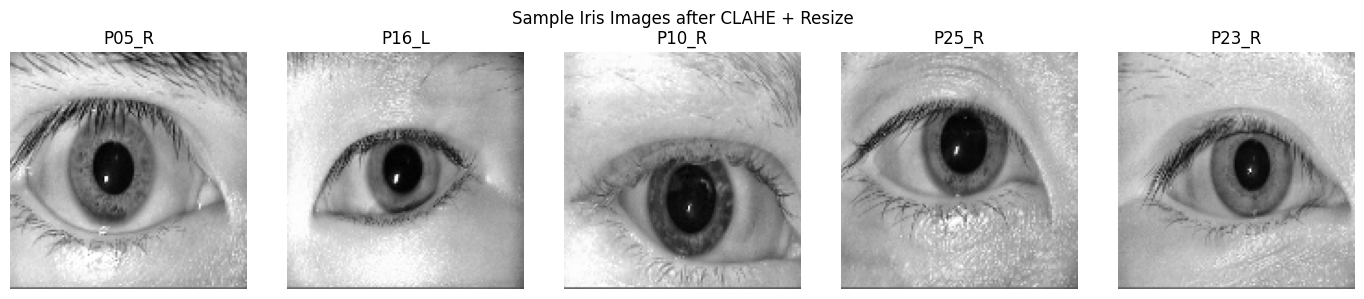

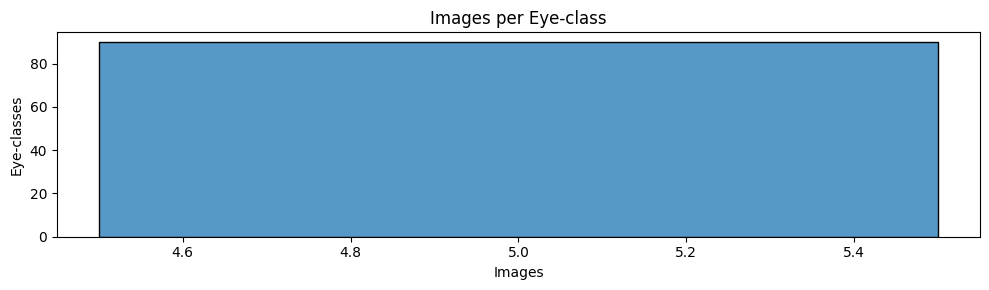

In [ ]:
import os
import cv2
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import defaultdict
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# CONFIGURATION
DATASET_PATH = "/content/MMU/MMU-Iris-Database"
IMG_SIZE     = (128, 128)
TRAIN_RATIO  = 0.8

# Helper: CLAHE for low-contrast iris images
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

def load_and_preprocess(path):
    """Read a single image file, grayscale -> CLAHE -> resize -> [0,1] normalise."""
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    img = clahe.apply(img)
    img = cv2.resize(img, IMG_SIZE)
    return img.astype(np.float32) / 255.0



eye_to_images = defaultdict(list)

person_dirs = sorted([d for d in os.listdir(DATASET_PATH)
                      if os.path.isdir(os.path.join(DATASET_PATH, d))])

for person in person_dirs:
    for side in ["left", "right"]:
        side_dir = os.path.join(DATASET_PATH, person, side)
        if not os.path.isdir(side_dir):
            continue
        # Sort filenames so the split is deterministic across runs.
        files = sorted(glob.glob(os.path.join(side_dir, "*.*")))

        try:
            pid = int(person)
            label = f"P{pid:02d}_{side[0].upper()}"
        except ValueError:
            label = f"{person}_{side[0].upper()}"
        for f in files:
            img = load_and_preprocess(f)
            if img is not None:                   # skip empty / corrupt files
                eye_to_images[label].append(img)

# Drop any eye that ended up with fewer than 2 images (can't train AND test).
eye_to_images = {k: v for k, v in eye_to_images.items() if len(v) >= 2}

print(f"Loaded {len(eye_to_images)} eye-classes.")
counts = [len(v) for v in eye_to_images.values()]
print(f"  Images per eye - min: {min(counts)}, max: {max(counts)}, "
      f"mean: {np.mean(counts):.2f}, total: {sum(counts)}")

# Per-eye 80/20 split
X_train, X_test, y_train_raw, y_test_raw = [], [], [], []

for eye_label, imgs in eye_to_images.items():
    imgs = list(imgs)
    random.Random(SEED).shuffle(imgs)
    n_train = max(1, int(round(len(imgs) * TRAIN_RATIO)))

    if n_train == len(imgs):
        n_train -= 1
    X_train.extend(imgs[:n_train])
    y_train_raw.extend([eye_label] * n_train)
    X_test.extend(imgs[n_train:])
    y_test_raw.extend([eye_label] * (len(imgs) - n_train))

X_train = np.array(X_train).reshape(-1, IMG_SIZE[0], IMG_SIZE[1], 1)
X_test  = np.array(X_test ).reshape(-1, IMG_SIZE[0], IMG_SIZE[1], 1)

# Encode string labels -> integers -> one-hot for classification training
label_encoder = LabelEncoder().fit(list(eye_to_images.keys()))
y_train_int   = label_encoder.transform(y_train_raw)
y_test_int    = label_encoder.transform(y_test_raw)
NUM_CLASSES   = len(label_encoder.classes_)
y_train       = to_categorical(y_train_int, NUM_CLASSES)
y_test        = to_categorical(y_test_int,  NUM_CLASSES)

print(f"  Train: {len(X_train)}, Test: {len(X_test)}, Classes (eyes): {NUM_CLASSES}")

# Quick sanity visualisation: one example from 5 random eyes
fig, axes = plt.subplots(1, 5, figsize=(14, 3))
sample_eyes = random.sample(list(eye_to_images.keys()), 5)
for ax, eye in zip(axes, sample_eyes):
    ax.imshow(eye_to_images[eye][0], cmap='gray')
    ax.set_title(eye); ax.axis('off')
plt.suptitle("Sample Iris Images after CLAHE + Resize")
plt.tight_layout(); plt.show()

# Class-count distribution plot
plt.figure(figsize=(10, 3))
sns.histplot(counts, bins=range(min(counts), max(counts) + 2), discrete=True)
plt.title("Images per Eye-class")
plt.xlabel("Images"); plt.ylabel("Eye-classes")
plt.tight_layout(); plt.show()


# **MobileNetV2**

RGB tensors: train (360, 128, 128, 3), test (90, 128, 128, 3)
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Total params: 2,433,562
Trainable (head only): 175,578

--- Stage 1: training the head with frozen MobileNetV2 backbone ---
Epoch 1/40
67/67 - 54s - 800ms/step - accuracy: 0.0360 - loss: 4.5021 - val_accuracy: 0.1889 - val_loss: 3.9095 - learning_rate: 0.0010
Epoch 2/40
67/67 - 1s - 13ms/step - accuracy: 0.1641 - loss: 3.5411 - val_accuracy: 0.4333 - val_loss: 2.7489 - learning_rate: 0.0010
Epoch 3/40
67/67 - 1s - 12ms/step - accuracy: 0.3740 - loss: 2.4596 - val_accuracy: 0.6222 - val_loss: 1.7804 - learning_rate: 0.0010
Epoch 4/40
67/67 - 1s - 14ms/step - accuracy: 0.5592 - loss: 1.6483 - val_accuracy: 0.7556 - val_loss: 1.2343 - learning_rate: 0.0010
Epoch 5/40
67/67 - 1s - 15ms/step - accuracy: 0.6918 - loss: 1.1398 - val_accuracy: 0.8222 - val_loss: 0.9357 - learning_rate: 0.0010
Epoch 6/40
67/67 - 1s - 14ms/step - accuracy: 0.7500 - loss: 0.9229 - val_accuracy: 0.8111 - 

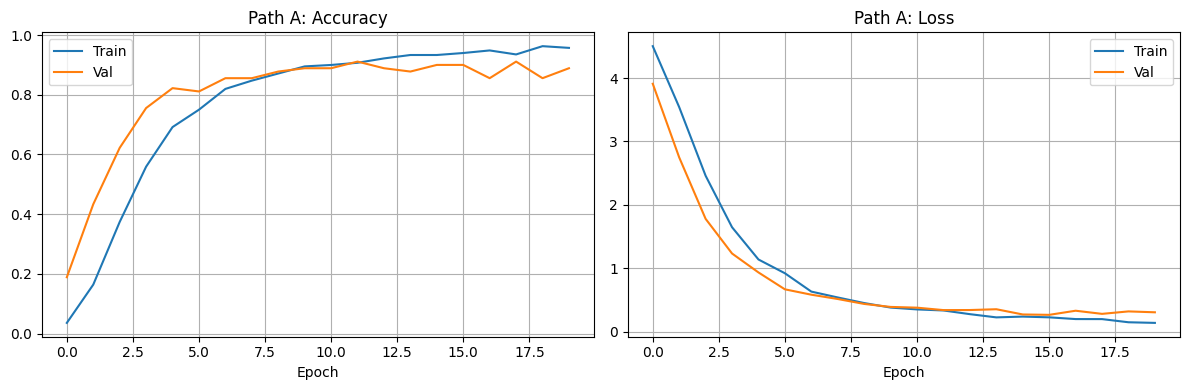


Best val accuracy: 0.911


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

tf.random.set_seed(SEED)


def to_rgb(x_gray):
    """(N, H, W, 1) float32 in [0,1]  ->  (N, H, W, 3) in MobileNetV2's expected range."""
    x3 = np.repeat(x_gray, 3, axis=-1)
    x3 = (x3 * 255.0).astype(np.float32)
    return preprocess_input(x3)

X_train_rgb = to_rgb(X_train)
X_test_rgb  = to_rgb(X_test)
print(f"RGB tensors: train {X_train_rgb.shape}, test {X_test_rgb.shape}")

# Build model: frozen MobileNetV2 backbone + trainable head
EMB_DIM_A = 128

backbone = MobileNetV2(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    include_top=False,
    weights='imagenet',
    pooling='avg',
)
backbone.trainable = False   # freeze during stage 1

inp = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
features = backbone(inp, training=False)
x = layers.Dropout(0.3)(features)
emb = layers.Dense(EMB_DIM_A, activation='relu',
                   name='embedding_layer')(x)
x = layers.Dropout(0.3)(emb)
out = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model_A = Model(inp, out)
model_A.compile(optimizer=Adam(1e-3),
                loss='categorical_crossentropy',
                metrics=['accuracy'])

print(f"Total params: {model_A.count_params():,}")
print(f"Trainable (head only): "
      f"{sum(tf.size(w).numpy() for w in model_A.trainable_weights):,}")


# simple tf.data pipeline to avoid ImageDataGenerator issues.
def augment_tf(img, label):
    img = tf.image.random_brightness(img, 0.15)
    img = tf.image.random_contrast(img, 0.85, 1.15)

    img = tf.image.resize_with_crop_or_pad(img, IMG_SIZE[0]+12, IMG_SIZE[1]+12)
    img = tf.image.random_crop(img, [IMG_SIZE[0], IMG_SIZE[1], 3])
    return img, label

BATCH_A = 16
train_ds = (tf.data.Dataset.from_tensor_slices((X_train_rgb, y_train))
            .shuffle(1024, seed=SEED)
            .map(augment_tf, num_parallel_calls=tf.data.AUTOTUNE)
            .batch(BATCH_A)
            .prefetch(tf.data.AUTOTUNE)
            .repeat())

val_ds = (tf.data.Dataset.from_tensor_slices((X_test_rgb, y_test))
          .batch(BATCH_A)
          .prefetch(tf.data.AUTOTUNE))

steps_per_epoch = max(30, (len(X_train_rgb) * 3) // BATCH_A)

callbacks_A = [
    EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5),
]

print("\n--- Stage 1: training the head with frozen MobileNetV2 backbone ---")
history_A = model_A.fit(
    train_ds,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_ds,
    epochs=40,
    callbacks=callbacks_A,
    verbose=2,
)

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_A.history['accuracy'],     label='Train')
axes[0].plot(history_A.history['val_accuracy'], label='Val')
axes[0].set_title('Path A: Accuracy'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True)
axes[1].plot(history_A.history['loss'],     label='Train')
axes[1].plot(history_A.history['val_loss'], label='Val')
axes[1].set_title('Path A: Loss'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(True)
plt.tight_layout(); plt.show()

print(f"\nBest val accuracy: {max(history_A.history['val_accuracy']):.3f}")


# **Verification Metrics and Spoofing**

90 templates, 90 probes
Genuine pairs: 90  |  Impostor pairs: 8010


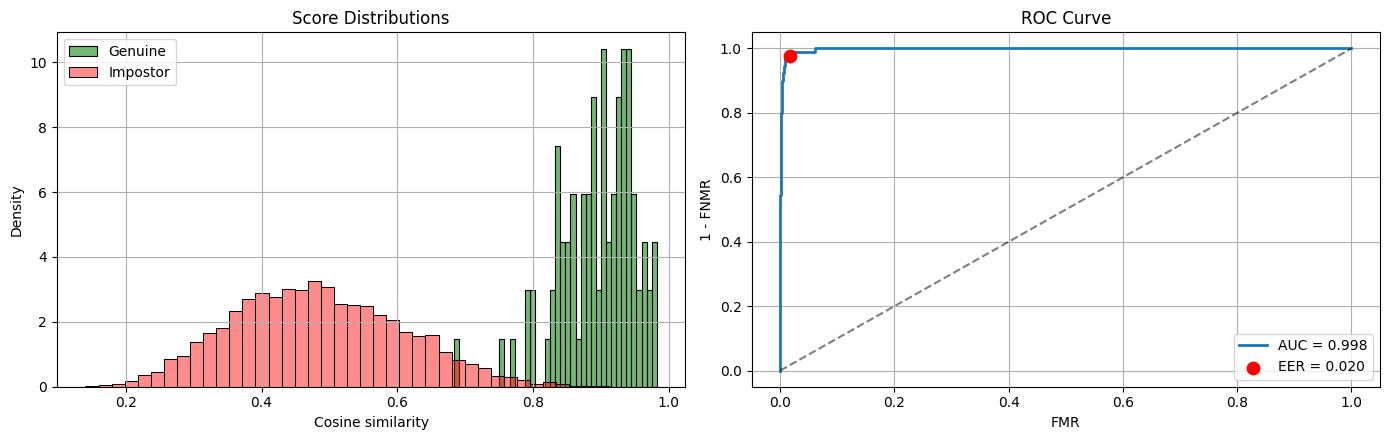

| Metric   |   Value |
|----------|---------|
| AUC      |  0.998  |
| EER      |  0.0201 |
| tau*     |  0.7547 |
| FMR      |  0.018  |
| FNMR     |  0.0222 |
| ATV      |  0.982  |
Blur                ATSR = 0.000  (0/90)
Gaussian Noise      ATSR = 0.100  (9/90)
Screen Glare        ATSR = 0.856  (77/90)
Low Resolution      ATSR = 0.011  (1/90)


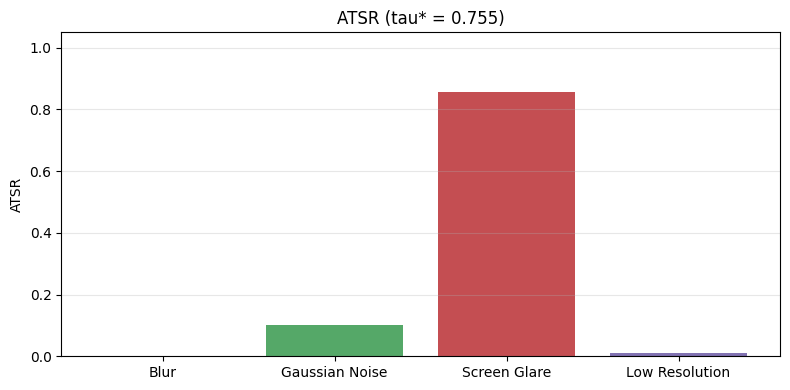

In [ ]:
from sklearn.metrics import roc_curve, auc
from tabulate import tabulate

# Extract embeddings
embedding_model_A = Model(inputs=model_A.input,
                          outputs=model_A.get_layer("embedding_layer").output)

def embed_A(x_rgb):
    if x_rgb.ndim == 3:
        x_rgb = x_rgb[None, ...]
    raw = embedding_model_A.predict(x_rgb, verbose=0)
    norms = np.linalg.norm(raw, axis=1, keepdims=True) + 1e-9
    return raw / norms

# Build master templates and probe embeddings
train_embs_A = embed_A(X_train_rgb)
train_lbls   = label_encoder.inverse_transform(np.argmax(y_train, axis=1))

master_templates_A = {}
for eye in label_encoder.classes_:
    idx = np.where(train_lbls == eye)[0]
    if len(idx) == 0: continue
    t = train_embs_A[idx].mean(axis=0)
    master_templates_A[eye] = t / (np.linalg.norm(t) + 1e-9)

probe_embs_A = embed_A(X_test_rgb)
probe_lbls   = label_encoder.inverse_transform(np.argmax(y_test, axis=1))

print(f"{len(master_templates_A)} templates, {len(probe_embs_A)} probes")

# Scoring
tmpl_labels_A = list(master_templates_A.keys())
tmpl_matrix_A = np.stack([master_templates_A[l] for l in tmpl_labels_A])
sim_matrix_A  = probe_embs_A @ tmpl_matrix_A.T

gen_A, imp_A = [], []
for i, pl in enumerate(probe_lbls):
    for j, tl in enumerate(tmpl_labels_A):
        (gen_A if pl == tl else imp_A).append(sim_matrix_A[i, j])
gen_A = np.array(gen_A); imp_A = np.array(imp_A)
print(f"Genuine pairs: {len(gen_A)}  |  Impostor pairs: {len(imp_A)}")

# ROC / EER
y_true_A  = np.concatenate([np.ones_like(gen_A), np.zeros_like(imp_A)])
y_score_A = np.concatenate([gen_A, imp_A])
fpr_A, tpr_A, thr_A = roc_curve(y_true_A, y_score_A)
auc_A = auc(fpr_A, tpr_A)
fnr_A = 1 - tpr_A
eer_idx_A = int(np.nanargmin(np.abs(fpr_A - fnr_A)))
eer_A     = (fpr_A[eer_idx_A] + fnr_A[eer_idx_A]) / 2
tau_A     = thr_A[eer_idx_A]

# Plots: score distributions + ROC
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(gen_A, bins=40, stat='density', color='green', alpha=0.55,
             label='Genuine', ax=axes[0])
sns.histplot(imp_A, bins=40, stat='density', color='red', alpha=0.45,
             label='Impostor', ax=axes[0])
axes[0].set_title("Score Distributions")
axes[0].set_xlabel("Cosine similarity"); axes[0].legend(); axes[0].grid(True)

axes[1].plot(fpr_A, tpr_A, lw=2, label=f"AUC = {auc_A:.3f}")
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].scatter(fpr_A[eer_idx_A], tpr_A[eer_idx_A], c='red', s=80, zorder=5,
                label=f"EER = {eer_A:.3f}")
axes[1].set_title("ROC Curve")
axes[1].set_xlabel("FMR"); axes[1].set_ylabel("1 - FNMR")
axes[1].legend(loc='lower right'); axes[1].grid(True)
plt.tight_layout(); plt.show()

#  Metrics @ threshold
TP = int((gen_A >= tau_A).sum()); FN = int((gen_A < tau_A).sum())
TN = int((imp_A <  tau_A).sum()); FP = int((imp_A >= tau_A).sum())
FMR_A  = FP / (FP + TN) if (FP + TN) else 0.0
FNMR_A = FN / (TP + FN) if (TP + FN) else 0.0
ATV_A  = (TP + TN) / (TP + FN + TN + FP)

print(tabulate([
    ["AUC",       f"{auc_A:.4f}"],
    ["EER",       f"{eer_A:.4f}"],
    ["tau*",      f"{tau_A:.4f}"],
    ["FMR",       f"{FMR_A:.4f}"],
    ["FNMR",      f"{FNMR_A:.4f}"],
    ["ATV",       f"{ATV_A:.4f}"],
], headers=["Metric", "Value"], tablefmt="github"))

# Spoofing
def attack_blur(img, k=15):   return cv2.GaussianBlur(img, (k, k), 0)
def attack_noise(img, s=0.08):
    return np.clip(img + np.random.normal(0, s, img.shape).astype(np.float32), 0, 1)
def attack_glare(img, b=60):
    i8 = (img * 255).astype(np.uint8)
    return cv2.convertScaleAbs(i8, alpha=1.0, beta=b).astype(np.float32) / 255.0
def attack_lowres(img, d=24):
    H, W = img.shape
    return cv2.resize(cv2.resize(img, (d, d)), (W, H))

ATTACKS = {"Blur": attack_blur, "Gaussian Noise": attack_noise,
           "Screen Glare": attack_glare, "Low Resolution": attack_lowres}

atsr_A = {}
for name, fn in ATTACKS.items():
    acc = att = 0
    for i in range(len(X_test)):
        eye = probe_lbls[i]
        if eye not in master_templates_A: continue
        img = X_test[i].reshape(IMG_SIZE)                # operate on grayscale
        spoofed = fn(img)
        spoofed_rgb = to_rgb(spoofed.reshape(1, IMG_SIZE[0], IMG_SIZE[1], 1))
        se = embed_A(spoofed_rgb)[0]
        sim = float(np.dot(se, master_templates_A[eye]))
        acc += int(sim >= tau_A); att += 1
    atsr_A[name] = acc / att if att else 0.0
    print(f"{name:<18}  ATSR = {atsr_A[name]:.3f}  ({acc}/{att})")

plt.figure(figsize=(8, 4))
plt.bar(atsr_A.keys(), atsr_A.values(),
        color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
plt.ylim(0, 1.05); plt.title(f"ATSR (tau* = {tau_A:.3f})")
plt.ylabel("ATSR"); plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


| Metric                      | Value           |
|-----------------------------|-----------------|
| Total images evaluated      | 450             |
| Quality threshold (5th pct) | 0.1730          |
| Failed enrolment (proxy)    | 23              |
| FTER proxy                  | 0.0511  (5.11%) |
| Mean Laplacian variance     | 2302.6          |
| Mean contrast (std)         | 49.1            |


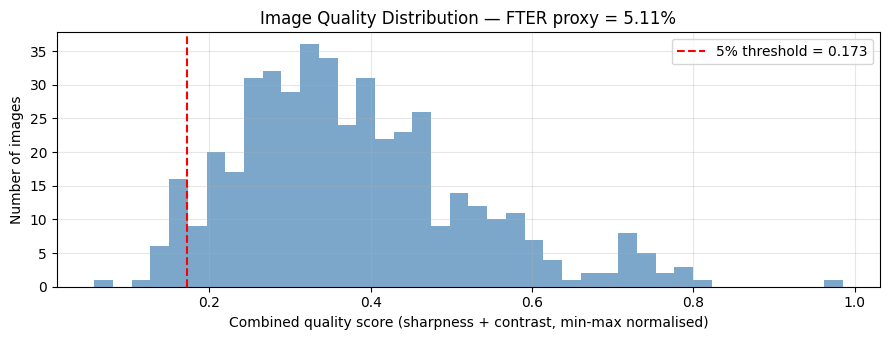

In [ ]:

#  FTER — Failure to Enrol Rate (quality-based proxy)


import cv2
import numpy as np
from tabulate import tabulate

def quality_score(img_uint8):
    """Combine sharpness + contrast. Higher = better enrolment candidate."""
    sharpness = cv2.Laplacian(img_uint8, cv2.CV_64F).var()
    contrast  = float(img_uint8.std())
    return sharpness, contrast

# Collect raw quality numbers for every image loaded
raw_scores = []
for eye, imgs in eye_to_images.items():
    for img in imgs:
        img_u8 = (img * 255).astype(np.uint8)
        raw_scores.append(quality_score(img_u8))

sharp = np.array([s[0] for s in raw_scores])
contr = np.array([s[1] for s in raw_scores])


sharp_n = (sharp - sharp.min()) / (sharp.max() - sharp.min() + 1e-9)
contr_n = (contr - contr.min()) / (contr.max() - contr.min() + 1e-9)
combined = 0.5 * sharp_n + 0.5 * contr_n


threshold = np.percentile(combined, 5)
n_failed  = int((combined < threshold).sum())
n_total   = len(combined)
fter_proxy = n_failed / n_total

print(tabulate([
    ["Total images evaluated",          n_total],
    ["Quality threshold (5th pct)",     f"{threshold:.4f}"],
    ["Failed enrolment (proxy)",        n_failed],
    ["FTER proxy",                      f"{fter_proxy:.4f}  ({fter_proxy*100:.2f}%)"],
    ["Mean Laplacian variance",         f"{sharp.mean():.1f}"],
    ["Mean contrast (std)",             f"{contr.mean():.1f}"],
], headers=["Metric", "Value"], tablefmt="github"))

# Visualise the quality distribution
import matplotlib.pyplot as plt
plt.figure(figsize=(9, 3.5))
plt.hist(combined, bins=40, color='steelblue', alpha=0.7)
plt.axvline(threshold, color='red', linestyle='--', label=f'5% threshold = {threshold:.3f}')
plt.xlabel("Combined quality score (sharpness + contrast, min-max normalised)")
plt.ylabel("Number of images")
plt.title(f"Image Quality Distribution — FTER proxy = {fter_proxy*100:.2f}%")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()